## Setup

In [1]:
import json
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from utils.general_utils import PROJECT_ROOT, binomial_unc_pct

PLOTS_ROOT = PROJECT_ROOT / "plots"
OUT_DIR    = PROJECT_ROOT / "plots" / "training-diagnostics"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAMES = ("cnn", "mlp", "hybrid")


def find_runs():
    """Every (model, target, tag) that has a saved history.

    Filenames are history_<model>_<tag>_<target>.pkl. tag can itself contain
    underscores (e.g. plus_bd), so parsing splits on the known model names and
    the two target names rather than blindly splitting on '_'.
    """
    runs = []
    for hist_path in PLOTS_ROOT.glob("*-classifier/*/history_*.pkl"):
        stem = hist_path.stem  # "history_<model>_<tag>_<target>"
        parts = stem.split("_")[1:]  # drop "history"

        if not parts or parts[0] not in MODEL_NAMES:
            print(f"skipping (unrecognised model): {hist_path.name}")
            continue
        if parts[-1] not in ("pion", "photon"):
            print(f"skipping (unrecognised target): {hist_path.name}")
            continue

        model  = parts[0]
        target = parts[-1]
        tag    = "_".join(parts[1:-1])
        runs.append((model, target, tag, hist_path))
    return sorted(runs)


def load_run(model, target, tag):
    """Returns (history, timing) or (None, None) if the history file is
    missing. Never raises -- callers decide what to do about a miss."""
    d = PLOTS_ROOT / f"{model}-classifier" / target
    hist_path   = d / f"history_{model}_{tag}_{target}.pkl"
    timing_path = d / f"timing_{model}_{tag}_{target}.json"

    if not hist_path.exists():
        return None, None

    with open(hist_path, "rb") as f:
        hist = pickle.load(f)
    timing = json.loads(timing_path.read_text()) if timing_path.exists() else None
    return hist, timing


runs = find_runs()
print(f"{len(runs)} saved runs:\n")
for model, target, tag, _ in runs:
    print(f"  {model:<8}{target:<8}{tag}")

4 saved runs:

  hybrid  photon  all8
  hybrid  photon  base4
  hybrid  pion    all8
  hybrid  pion    base4


## pick what to compare

In [2]:
# Edit this list. Each entry is (model, target, tag, colour, display_name).
SELECTION = [
    ("cnn",    "photon", "seq",   "steelblue",   "CNN (photon)"),
    ("mlp",    "photon", "base4", "darkorange",  "MLP (photon)"),
    ("hybrid", "photon", "all8",  "crimson",     "Hybrid all8 (photon)"),
    ("hybrid", "pion",   "base4", "grey",        "Hybrid base4 (pion)"),
    ("hybrid", "pion",   "all8",  "firebrick",   "Hybrid all8 (pion)"),
    ("cnn",    "pion",   "seq",   "teal",        "CNN (pion)"),
    ("mlp",    "pion",   "base4", "green",        "MLP (pion)"),
]

all_data = {}     # everything found on disk -- used by the timing cell
data     = {}     # only runs with train-side history -- used by the plots
missing, no_train = [], []

for model, target, tag, colour, label in SELECTION:
    hist, timing = load_run(model, target, tag)
    if hist is None:
        missing.append(f"{model}/{target}/{tag}")
        continue

    entry = {'history': hist, 'timing': timing, 'colour': colour}
    all_data[label] = entry

    if hist.get('train_purity'):
        data[label] = entry
        n_ep = len(hist['val_loss'])
        print(f"{label:<26} {n_ep} epochs")
    else:
        no_train.append(label)

if missing:
    print(f"\nnot found on disk:")
    for m in missing:
        print(f"  {m}")

if no_train:
    print(f"\nfound, but no train-side history (excluded from the plots below, "
          f"still shown in timing):")
    for label in no_train:
        print(f"  {label}")

if not data:
    print("\nnothing with train-side history -- cells 3-4 will have nothing to plot.")
    print("Re-run with --train-eval-every N to get it.")

Hybrid all8 (photon)       34 epochs
Hybrid base4 (pion)        25 epochs
Hybrid all8 (pion)         54 epochs

not found on disk:
  cnn/photon/seq
  mlp/photon/base4
  cnn/pion/seq
  mlp/pion/base4


## training curves, all selected runs

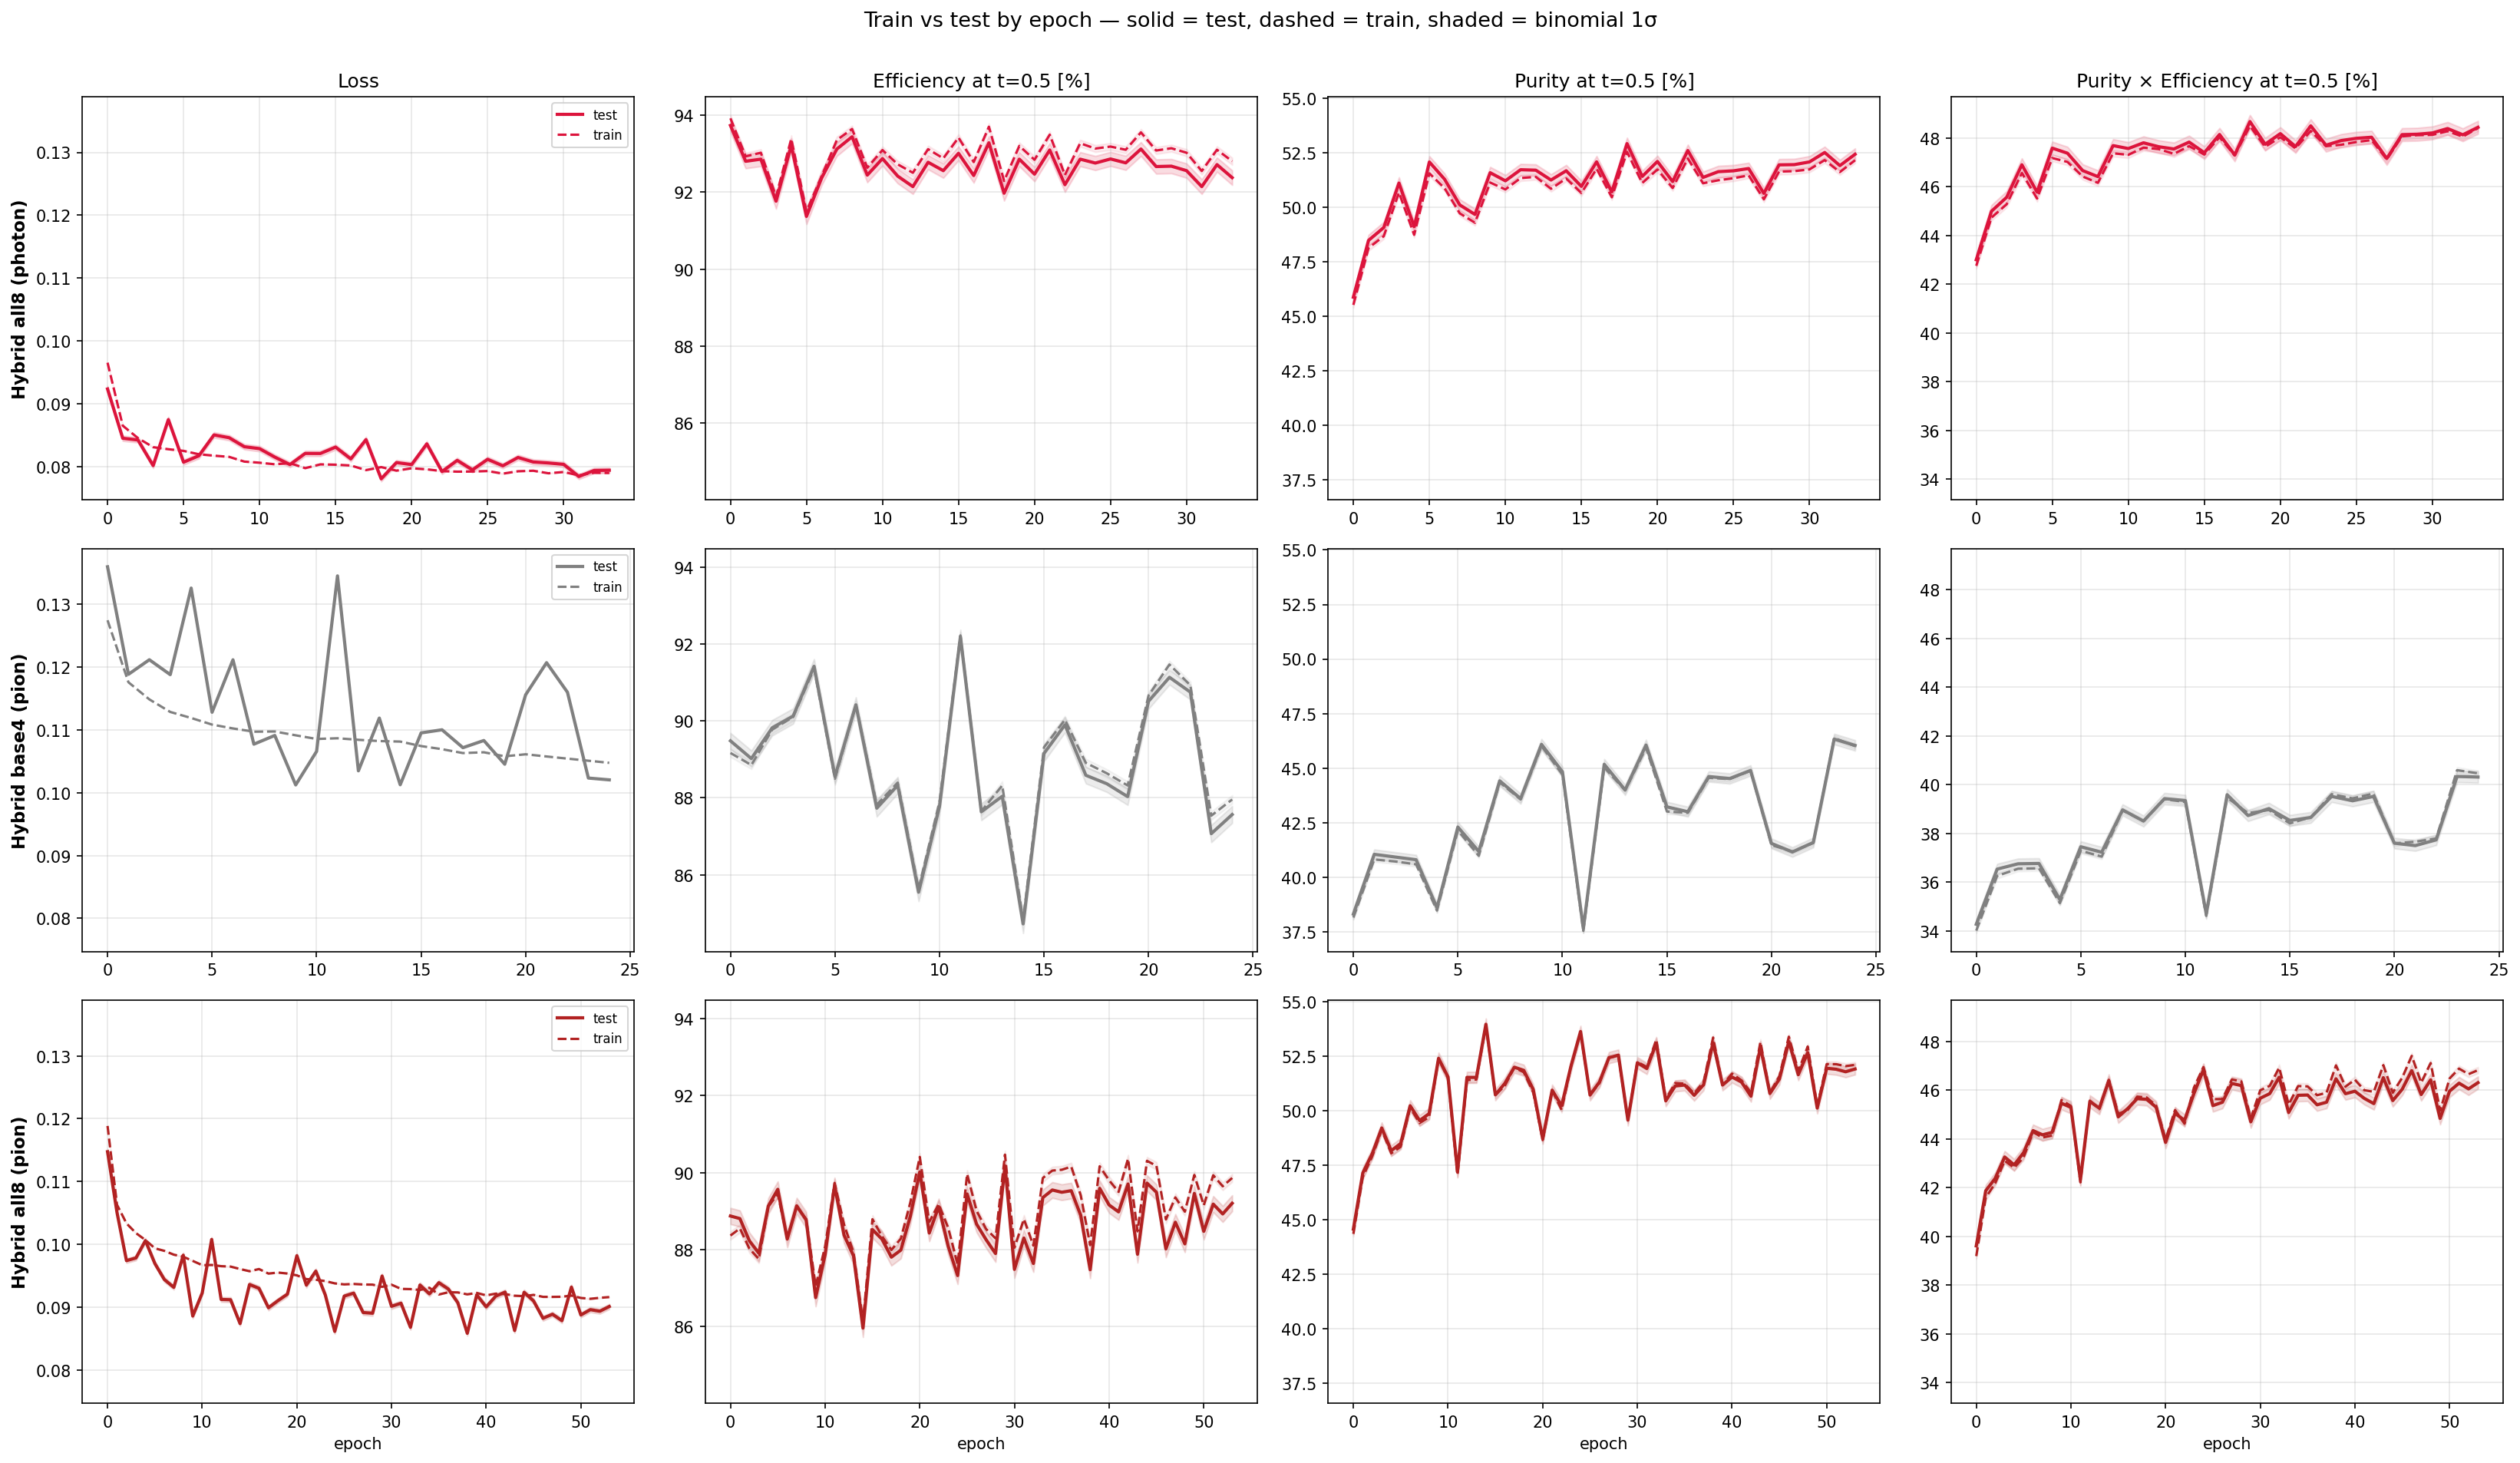

run                           epochs   train pur   test pur     gap
-------------------------------------------------------------------
Hybrid all8 (photon)              34       52.2%      52.4%   -0.3pp
Hybrid base4 (pion)               25       46.0%      46.0%   -0.0pp
Hybrid all8 (pion)                54       52.1%      51.9%   +0.2pp


In [4]:
if not data:
    print("nothing to plot -- see cell 2")
else:
    n_models = len(data)
    fig, ax = plt.subplots(n_models, 4, figsize=(22, 4.2 * n_models), dpi=150,
                           squeeze=False, sharey='col')

    for row, (label, d) in enumerate(data.items()):
        h, c = d['history'], d['colour']
        ep = np.arange(len(h['val_loss']))
        te = h['train_epoch']

        eff = np.array(h['efficiency']) * 100
        pur = np.array(h['purity']) * 100
        tr_eff = np.array(h['train_efficiency']) * 100
        tr_pur = np.array(h['train_purity']) * 100

        pxe    = pur * eff / 100
        tr_pxe = tr_pur * tr_eff / 100

        # --- col 0: loss ---
        ax[row, 0].plot(ep, h['val_loss'], color=c, lw=2, label='test')
        ax[row, 0].plot(ep, h['train_loss'], color=c, lw=1.5, ls='--', label='train')
        if h.get('val_loss_sem'):
            v = np.array(h['val_loss']); ve = np.array(h['val_loss_sem'])
            ax[row, 0].fill_between(ep, v-ve, v+ve, color=c, alpha=0.15)
        if h.get('train_loss_sem'):
            tl = np.array(h['train_loss']); tle = np.array(h['train_loss_sem'])
            ax[row, 0].fill_between(ep, tl-tle, tl+tle, color=c, alpha=0.08)
        ax[row, 0].set_ylabel(label, fontsize=11, fontweight='bold')

        # --- col 1: efficiency ---
        ax[row, 1].plot(ep, eff, color=c, lw=2)
        ax[row, 1].plot(te, tr_eff, color=c, lw=1.5, ls='--')
        n_sig, n_sig_tr = h.get('n_test_sig'), h.get('n_train_sig')
        eff_err = tr_eff_err = None
        if n_sig and n_sig_tr:
            eff_err    = np.array([binomial_unc_pct(e/100*n_sig, n_sig) for e in eff])
            tr_eff_err = np.array([binomial_unc_pct(e/100*n_sig_tr, n_sig_tr) for e in tr_eff])
            ax[row, 1].fill_between(ep, eff-eff_err, eff+eff_err, color=c, alpha=0.15)
            ax[row, 1].fill_between(te, tr_eff-tr_eff_err, tr_eff+tr_eff_err, color=c, alpha=0.08)

        # --- col 2: purity ---
        ax[row, 2].plot(ep, pur, color=c, lw=2)
        ax[row, 2].plot(te, tr_pur, color=c, lw=1.5, ls='--')
        n_tag, n_tag_tr = h.get('n_test_tagged'), h.get('n_train_tagged')
        pur_err = tr_pur_err = None
        if n_tag and n_tag_tr:
            n_tag, n_tag_tr = np.array(n_tag), np.array(n_tag_tr)
            pur_err    = np.array([binomial_unc_pct(p/100*n, n) for p, n in zip(pur, n_tag)])
            tr_pur_err = np.array([binomial_unc_pct(p/100*n, n) for p, n in zip(tr_pur, n_tag_tr)])
            ax[row, 2].fill_between(ep, pur-pur_err, pur+pur_err, color=c, alpha=0.15)
            ax[row, 2].fill_between(te, tr_pur-tr_pur_err, tr_pur+tr_pur_err, color=c, alpha=0.08)

        # --- col 3: purity x efficiency ---
        ax[row, 3].plot(ep, pxe, color=c, lw=2)
        ax[row, 3].plot(te, tr_pxe, color=c, lw=1.5, ls='--')
        if eff_err is not None and pur_err is not None:
            # quadrature combination of the two relative errors, as an
            # approximation -- purity and efficiency are not strictly
            # independent since both come from the same tagged set.
            rel = np.sqrt((eff_err/np.clip(eff, 1e-6, None))**2 +
                         (pur_err/np.clip(pur, 1e-6, None))**2)
            pxe_err = pxe * rel
            ax[row, 3].fill_between(ep, pxe-pxe_err, pxe+pxe_err, color=c, alpha=0.15)
        if tr_eff_err is not None and tr_pur_err is not None:
            rel_tr = np.sqrt((tr_eff_err/np.clip(tr_eff, 1e-6, None))**2 +
                            (tr_pur_err/np.clip(tr_pur, 1e-6, None))**2)
            tr_pxe_err = tr_pxe * rel_tr
            ax[row, 3].fill_between(te, tr_pxe-tr_pxe_err, tr_pxe+tr_pxe_err,
                                    color=c, alpha=0.08)

        titles = ['Loss', 'Efficiency at t=0.5 [%]', 'Purity at t=0.5 [%]',
                 'Purity × Efficiency at t=0.5 [%]']
        for col, title in enumerate(titles):
            ax[row, col].grid(alpha=0.3)
            if row == 0:
                ax[row, col].set_title(title)
            if row == n_models - 1:
                ax[row, col].set_xlabel('epoch')
        ax[row, 0].legend(fontsize=8)

    fig.suptitle('Train vs test by epoch — solid = test, dashed = train, '
                 'shaded = binomial 1σ', fontsize=13, y=1.005)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "overfitting_comparison.pdf", bbox_inches='tight')
    plt.show()

    print(f"{'run':<28}{'epochs':>8}{'train pur':>12}{'test pur':>11}{'gap':>8}")
    print("-" * 67)
    for label, d in data.items():
        h = d['history']
        gtr, gte = 100*h['train_purity'][-1], 100*h['purity'][-1]
        print(f"{label:<28}{len(h['val_loss']):>8}{gtr:>11.1f}%{gte:>10.1f}%{gtr-gte:>+7.1f}pp")

## timing comparison

In [5]:
if not all_data:
    print("nothing to show -- see cell 2")
else:
    print(f"{'run':<28}{'epochs':>8}{'total':>10}{'per epoch':>12}{'device':>8}")
    print("-" * 66)
    for label, d in all_data.items():
        t = d['timing']
        if t is None:
            print(f"{label:<28}{'(no timing.json for this run)':>50}")
            continue
        epochs, seconds = t.get('epochs'), t.get('seconds')
        if epochs is None or seconds is None:
            print(f"{label:<28}{'(timing.json missing expected fields)':>50}")
            continue
        s_per_epoch = t.get('s_per_epoch', seconds / max(epochs, 1))
        print(f"{label:<28}{epochs:>8}{seconds:>9.0f}s{s_per_epoch:>11.1f}s"
              f"{t.get('device', '?'):>8}")

run                           epochs     total   per epoch  device
------------------------------------------------------------------
Hybrid all8 (photon)              34     3690s      108.5s     cpu
Hybrid base4 (pion)               25     3231s      129.3s     cpu
Hybrid all8 (pion)                54     6333s      117.3s     cpu
